### 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

2026-03-09 18:22:42.417865: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 18:22:42.546334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 18:22:44.707177: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2. Load Dataset

In [2]:
print("LOADING MNIST DATASET")
print("-" * 50)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train[:6000]
y_train = y_train[:6000]

x_test = x_test[:1000]
y_test = y_test[:1000]

print("Reduced training shape:", x_train.shape)
print("Reduced testing shape:", x_test.shape)

LOADING MNIST DATASET
--------------------------------------------------
Reduced training shape: (6000, 28, 28)
Reduced testing shape: (1000, 28, 28)


### 3. Training Dataset 

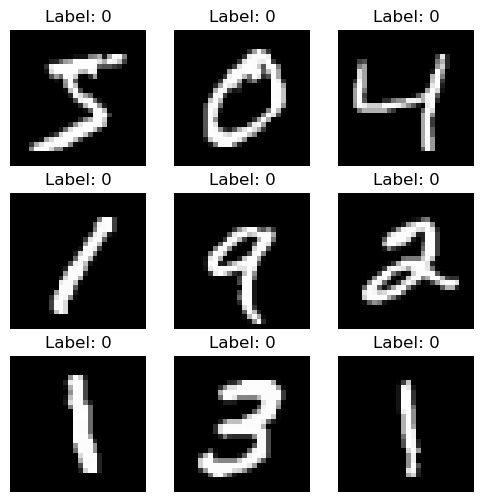

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Label: " + str(np.argmax(y_train[i])))
    plt.axis('off')

plt.show()

### 4. Normalize and Reshape Data

In [4]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (6000, 28, 28, 1)
Test shape: (1000, 28, 28, 1)


### 5. Convert Labels to One Hot

In [5]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

### 6. Create Validation Split

In [6]:
x_train_new, x_val, y_train_new, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42
)

print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)

Training: (5400, 28, 28, 1)
Validation: (600, 28, 28, 1)


### 7. Data Augmentation

In [7]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train_new)

### 8. Improved CNN Model

In [8]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/ridhurshan/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-09 18:22:45.905585: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Callbacks

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

### 10. Train Model

In [10]:
history = model.fit(
    datagen.flow(x_train_new, y_train_new, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50


/home/ridhurshan/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5359 - loss: 1.4034 - val_accuracy: 0.9117 - val_loss: 0.3373 - learning_rate: 0.0010
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8102 - loss: 0.6220 - val_accuracy: 0.9267 - val_loss: 0.2360 - learning_rate: 0.0010
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8535 - loss: 0.4577 - val_accuracy: 0.9533 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8893 - loss: 0.3589 - val_accuracy: 0.9517 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9035 - loss: 0.3199 - val_accuracy: 0.9617 - val_loss: 0.1307 - learning_rate: 0.0010
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9141 - loss: 0.2848 - val_accuracy: 0.9633 - val_loss: 0.1372 - learning_rate: 0.0010
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9206 - loss: 0.2677 - val_accuracy: 0.96

### 11. Plot Accuracy & Loss

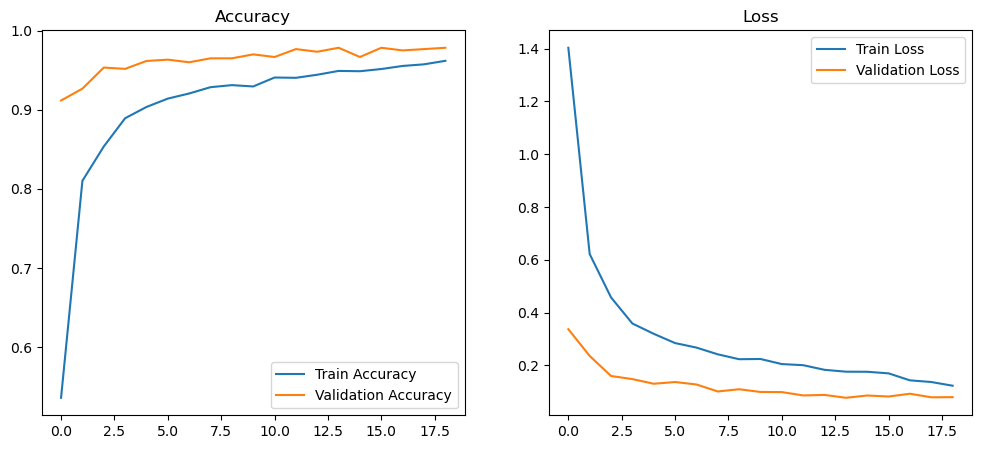

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

### 12. Evaluate Model

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9810 - loss: 0.0494
Test Accuracy: 0.9810000061988831


### 13. Confusion Matrix

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


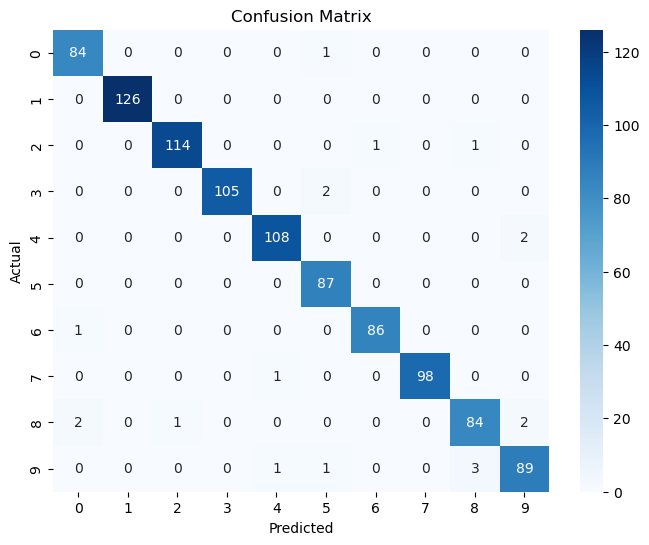

In [13]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 13.Save Final Model

In [14]:
model.save("model_v2.h5")

print("Final model saved as model_v2.h5")

Final model saved as model_v2.h5


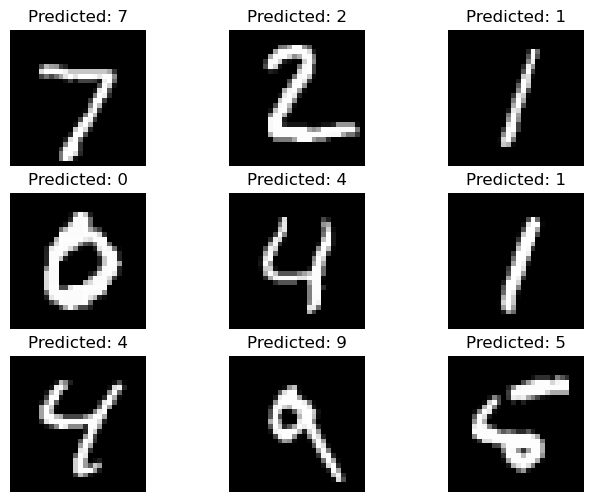

In [15]:
plt.figure(figsize=(8,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Predicted: " + str(y_pred_classes[i]))
    plt.axis('off')

plt.show()